# Assignment 2 — Text Classification: IMDB Movie Reviews

**Student:** *Thomas Schlaerth*
**Dataset:** IMDB 50K Movie Reviews — https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


In [11]:
# Core
import os, re, time, warnings, random
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score, accuracy_score)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Make figures directory
os.makedirs("../figures", exist_ok=True)
sns.set_style("whitegrid")
print("Setup complete.")


Setup complete.


## 1. Load the dataset

In [12]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
csv_file_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(csv_file_path)
print(f"Shape: {df.shape}")
df.head(3)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 2. Exploratory Data Analysis

### 2.1 Metadata


In [13]:
print("Columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Columns: ['review', 'sentiment']

Dtypes:
 review       object
sentiment    object
dtype: object

Missing values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418


In [14]:
# Drop duplicates if any
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicates. New shape: {df.shape}")


Removed 418 duplicates. New shape: (49582, 2)


### 2.2 Class distribution

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Ratio (majority/minority): 1.01


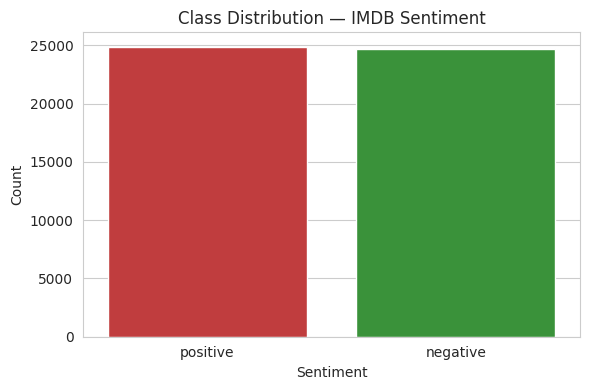

In [15]:
class_counts = df['sentiment'].value_counts()
print(class_counts)
print(f"\nRatio (majority/minority): {class_counts.max()/class_counts.min():.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette=['#d62728', '#2ca02c'], ax=ax)
ax.set_title("Class Distribution — IMDB Sentiment")
ax.set_xlabel("Sentiment"); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/class_distribution.png", dpi=150)
plt.show()


### 2.3 Text length analysis by class

           n_chars                                                       \
             count    mean     std   min    25%    50%     75%      max   
sentiment                                                                 
negative   24698.0  1294.7   946.5  32.0  706.0  974.0  1568.0   8969.0   
positive   24884.0  1326.3  1032.6  65.0  692.0  969.0  1615.2  13704.0   

           n_words                                                   
             count   mean    std   min    25%    50%    75%     max  
sentiment                                                            
negative   24698.0  229.6  165.1   4.0  128.0  174.0  278.0  1522.0  
positive   24884.0  233.1  177.7  10.0  125.0  172.0  284.0  2470.0  


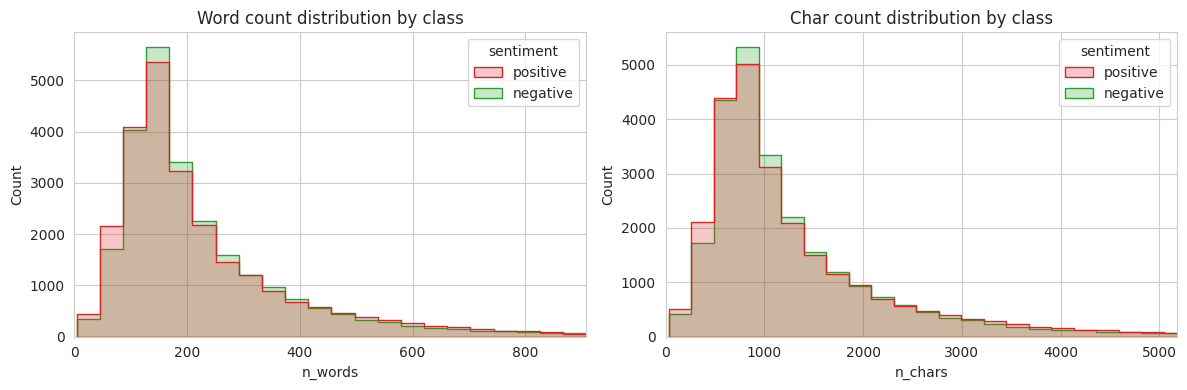

In [16]:
df['n_chars']   = df['review'].str.len()
df['n_words']   = df['review'].str.split().str.len()

print(df.groupby('sentiment')[['n_chars', 'n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['n_words', 'n_chars'], ['Word count', 'Char count']):
    sns.histplot(data=df, x=col, hue='sentiment', bins=60, kde=False,
                 element='step', ax=ax, palette=['#d62728', '#2ca02c'])
    ax.set_xlim(0, df[col].quantile(0.99))
    ax.set_title(f"{title} distribution by class")
plt.tight_layout()
plt.savefig("../figures/text_length_by_class.png", dpi=150)
plt.show()


### 2.4 Most frequent words per class


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Light, temporary cleaner just for vocabulary peek (real cleaning is in Step 3)
def quick_clean(s):
    s = re.sub(r"<br ?/?>", " ", s.lower())
    s = re.sub(r"[^a-z\s]", " ", s)
    return s

cv_peek = CountVectorizer(stop_words='english', max_features=30)

for label in ['positive', 'negative']:
    texts = df.loc[df['sentiment'] == label, 'review'].apply(quick_clean)
    cv_peek.fit(texts)
    counts = np.asarray(cv_peek.transform(texts).sum(axis=0)).ravel()
    top = sorted(zip(cv_peek.get_feature_names_out(), counts), key=lambda x: -x[1])[:15]
    print(f"\nTop 15 words in {label.upper()} reviews:")
    for w, c in top:
        print(f"  {w:<15} {c}")



Top 15 words in POSITIVE reviews:
  film            41971
  movie           37660
  like            17651
  good            14966
  just            14057
  story           12899
  great           12889
  time            12701
  really          10707
  people          8685
  love            8658
  best            8480
  life            8105
  way             7833
  films           7581

Top 15 words in NEGATIVE reviews:
  movie           49618
  film            37180
  like            22192
  just            20870
  good            14581
  bad             14563
  really          12217
  time            12205
  don             10502
  story           10074
  people          9337
  make            9266
  movies          8246
  plot            8128
  acting          8004


The top words used within the reviews are similar in the sense that they are general with words like "move" and "film" appearing in nearly every review. This is understandable because most reviews mention the movie before speaking on specifics which influence the positive or negative sentiment. The top positive review words have an impact on how the viewer is feeling, i.e. "love", "great", "best", "life". Whereas the top negative reviews are critiques on the movie specifically, i.e. "story", "plot", "acting".

## 3. Text Cleaning

### 3.1 Justification (sentiment-specific)

| Decision | Rationale |
|---|---|
| **Lowercase** | Reduces sparsity; "Good" and "good" should map to one feature. |
| **Remove HTML `<br />`** | These are markup artifacts from the source HTML, not signal. |
| **Strip non-alphabetic except `!`, `?`** | We keep `!` and `?` because emphatic punctuation carries sentiment (`"awful!!!"` != `"awful"`). |
| **Keep negation words** (don't, not, no, never) | "not good" and "good" must remain distinguishable — we do NOT strip stopwords during cleaning. We let the vectorizer use bigrams to capture negation. |
| **Do NOT lemmatize/stem aggressively** | "loved" vs "loving" carry tense nuance; aggressive stemming has been shown to hurt sentiment models. |
| **Collapse repeated chars** ("sooo good") → ("soo good") | Reduces vocabulary explosion without losing emphasis. |

### 3.2 Implementation


In [18]:
def clean_text(text: str) -> str:
    # 1) lowercase
    text = text.lower()
    # 2) strip HTML breaks
    text = re.sub(r"<br ?/?>", " ", text)
    # 3) keep letters, spaces, ! and ?
    text = re.sub(r"[^a-z!?\s]", " ", text)
    # 4) collapse 3+ repeated chars to 2 ("sooo" -> "soo")
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # 5) collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text)

# Before/after examples for each class
print("=" * 70)
for label in ['positive', 'negative']:
    sample = df[df['sentiment'] == label].sample(1, random_state=RANDOM_STATE).iloc[0]
    print(f"[{label.upper()}]")
    print("BEFORE:", sample['review'][:250], "...")
    print("AFTER :", sample['review_clean'][:250], "...")
    print("=" * 70)


[POSITIVE]
BEFORE: Not since The Simpsons made it's debut has there been a sitcom that I didn't want to turn of in a matter of 2 minutes. It has of course been said that The Simpsons killed the sitcom. Not this one though.<br /><br />The first season was so so as the t ...
AFTER : not since the simpsons made it s debut has there been a sitcom that i didn t want to turn of in a matter of minutes it has of course been said that the simpsons killed the sitcom not this one though the first season was so so as the teenage character ...
[NEGATIVE]
BEFORE: I usually much prefer French movies over American ones, with explosions and car chases, but this movie was very disappointing. There is no way to write a spoiler because nothing really happens. This French couple has been living in Lisbon for years,  ...
AFTER : i usually much prefer french movies over american ones with explosions and car chases but this movie was very disappointing there is no way to write a spoiler because nothing really

## 4. Feature Engineering

I will compare **three** vectorization approaches:

- **A. TF-IDF, unigrams only** — classic baseline.
- **B. TF-IDF, unigrams + bigrams** — captures negation patterns ("not good", "very disappointing").
- **C. Count Vectorizer, unigrams + bigrams** — same n-grams but raw counts instead of TF-IDF weighting.

Vocabulary size capped at **5000** features

### 4.1 Train/test split (stratified)


In [19]:
y = (df['sentiment'] == 'positive').astype(int).values
texts = df['review_clean'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {len(X_train_text)}, Test: {len(X_test_text)}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")


Train: 39665, Test: 9917
Train class balance: [19758 19907]
Test  class balance: [4940 4977]


### 4.2 Build and compare the three vectorizers

In [20]:
STOP = 'english'
MAX_FEAT = 5000

vectorizers = {
    "TFIDF_uni":     TfidfVectorizer(max_features=MAX_FEAT, ngram_range=(1,1),
                                     stop_words=STOP, min_df=5),
    "TFIDF_uni_bi":  TfidfVectorizer(max_features=MAX_FEAT, ngram_range=(1,2),
                                     stop_words=STOP, min_df=5),
    "Count_uni_bi":  CountVectorizer(max_features=MAX_FEAT, ngram_range=(1,2),
                                     stop_words=STOP, min_df=5),
}

fe_results = []
for name, vec in vectorizers.items():
    Xtr = vec.fit_transform(X_train_text)
    Xte = vec.transform(X_test_text)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                             random_state=RANDOM_STATE)
    t0 = time.time()
    clf.fit(Xtr, y_train)
    fit_time = time.time() - t0
    yhat = clf.predict(Xte)
    fe_results.append({
        "vectorizer": name,
        "vocab_size": len(vec.vocabulary_),
        "fit_time_s": round(fit_time, 2),
        "test_F1":    round(f1_score(y_test, yhat), 4),
        "test_acc":   round(accuracy_score(y_test, yhat), 4),
    })

fe_df = pd.DataFrame(fe_results)
print(fe_df.to_string(index=False))


  vectorizer  vocab_size  fit_time_s  test_F1  test_acc
   TFIDF_uni        5000        0.68   0.8873    0.8852
TFIDF_uni_bi        5000        0.37   0.8881    0.8863
Count_uni_bi        5000        2.53   0.8781    0.8775


Looking at the F1 scores for all three approaches TF-IDF with bigrams outperformed the other two by very slight margins. The baseline TF-IDF performed second best with the second fastest fit time. The slowest and weakest of the three was the CountVectorizer. The best choice is to use the TF-IDF bigrams purely on numbers alone.

In [21]:
BEST_VEC_NAME = "TFIDF_uni_bi"
best_vec = vectorizers[BEST_VEC_NAME]

X_train = best_vec.fit_transform(X_train_text)
X_test  = best_vec.transform(X_test_text)
print(f"Using {BEST_VEC_NAME}: train shape = {X_train.shape}, test shape = {X_test.shape}")


Using TFIDF_uni_bi: train shape = (39665, 5000), test shape = (9917, 5000)


## 5. Model Training

Three algorithms, all trained on the chosen vectorization:
1. **Logistic Regression** — fast, interpretable, good baseline.
2. **Multinomial Naive Bayes** — very fast, works well with counts.
3. **Linear SVM** — good for high-dimensional text data.

### 5.1 Train all three and time them


In [22]:
models = {
    "LogReg":  LogisticRegression(max_iter=1000, class_weight='balanced',
                                  C=1.0, random_state=RANDOM_STATE),
    "MultNB":  MultinomialNB(),   # NB doesn't accept class_weight; data is balanced anyway
    "LinSVM":  LinearSVC(class_weight='balanced', C=1.0, random_state=RANDOM_STATE),
}

trained = {}
timings = {}
preds   = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    timings[name] = round(time.time() - t0, 3)
    preds[name]   = model.predict(X_test)
    trained[name] = model
    print(f"{name:<8} fit in {timings[name]:>6}s, "
          f"test F1 = {f1_score(y_test, preds[name]):.4f}, "
          f"test acc = {accuracy_score(y_test, preds[name]):.4f}")


LogReg   fit in   0.37s, test F1 = 0.8881, test acc = 0.8863
MultNB   fit in  0.037s, test F1 = 0.8594, test acc = 0.8568
LinSVM   fit in  0.989s, test F1 = 0.8859, test acc = 0.8848


### 5.2 Hyperparameter tuning


In [23]:
# Tune the regularization strength of LogReg
param_grid = {"C": [0.1, 0.5, 1.0, 2.0, 4.0]}

gs = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='f1',
    cv=3, n_jobs=-1, verbose=1,
)
gs.fit(X_train, y_train)
print("Best C:", gs.best_params_)
print("CV F1 :", round(gs.best_score_, 4))

# Replace LogReg with the tuned model
trained["LogReg_tuned"] = gs.best_estimator_
preds["LogReg_tuned"]   = gs.best_estimator_.predict(X_test)
timings["LogReg_tuned"] = timings["LogReg"]   # approx — final-refit time is small
print("Tuned LogReg test F1:", round(f1_score(y_test, preds['LogReg_tuned']), 4))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best C: {'C': 2.0}
CV F1 : 0.8865
Tuned LogReg test F1: 0.8886


## 6. Evaluation & Comparison

### 6.1 Classification reports for every model


In [24]:
for name, yhat in preds.items():
    print(f"\n===== {name} =====")
    print(classification_report(y_test, yhat,
                                target_names=['negative', 'positive'],
                                digits=4))



===== LogReg =====
              precision    recall  f1-score   support

    negative     0.8958    0.8733    0.8844      4940
    positive     0.8773    0.8991    0.8881      4977

    accuracy                         0.8863      9917
   macro avg     0.8865    0.8862    0.8862      9917
weighted avg     0.8865    0.8863    0.8862      9917


===== MultNB =====
              precision    recall  f1-score   support

    negative     0.8671    0.8415    0.8541      4940
    positive     0.8472    0.8720    0.8594      4977

    accuracy                         0.8568      9917
   macro avg     0.8571    0.8568    0.8568      9917
weighted avg     0.8571    0.8568    0.8568      9917


===== LinSVM =====
              precision    recall  f1-score   support

    negative     0.8885    0.8791    0.8838      4940
    positive     0.8813    0.8905    0.8859      4977

    accuracy                         0.8848      9917
   macro avg     0.8849    0.8848    0.8848      9917
weighted avg  

### 6.2 Confusion matrices

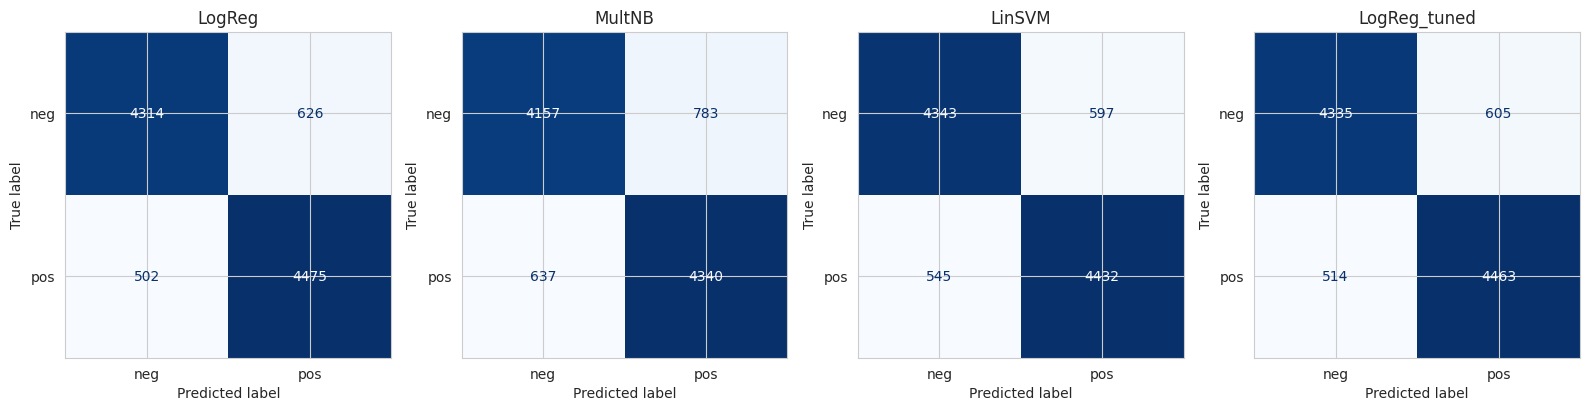

In [25]:
fig, axes = plt.subplots(1, len(preds), figsize=(4*len(preds), 4))
if len(preds) == 1:
    axes = [axes]
for ax, (name, yhat) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, yhat)
    ConfusionMatrixDisplay(cm, display_labels=['neg', 'pos']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name)
plt.tight_layout()
plt.savefig("../figures/confusion_matrices.png", dpi=150)
plt.show()


### 6.3 Important class identification

For this dataset positive class matter more than negative class for movie reviews specifically. Other reviews can be seen as neutral or negative which are not as clear for seeing the sentiment of the review. If this dataset were to be used for future movie creation or as a recommender for other viewers to watch movies, a clear positive sentiment is crucial. Mixed or negative reviews are not as helpful for improving movies and movie watchers do not want to be recommended poor movies. When deciding which model to use we want to see the highest true positives predicted with the least amount of false positives. Using this logic, the Tuned Logistiic Regression model works best. It has the highest F1-score while also having one of the lowest false postive rates.

---

### 6.4 Random 20-row manual review

We sample 20 test rows. For each, you will compare the *true* label, the *predicted* label, and the *text itself*, then mark whether you agree with the model's prediction.


In [28]:
# 20 Random Reviews
best_name  = "LogReg_tuned"
best_model = trained[best_name]
best_preds = preds[best_name]

np.random.seed(42)
sample_idx = np.random.choice(len(X_test_text), size=20, replace=False)

# Text and model prediction
review_df = pd.DataFrame({
    'Text': [X_test_text[idx] for idx in sample_idx],
    'Model Prediction': ['positive' if best_preds[idx] == 1 else 'negative'
                         for idx in sample_idx],
    'Manual Prediction': ''  # Fill in Excel
})

review_df.index = range(1, 21)
review_df.to_excel('../figures/random_imdb_reviews.xlsx', index_label='#')
print('Exported to random_imdb_reviews.xlsx')

Exported to random_imdb_reviews.xlsx


In [31]:
from google.colab import files

# Provide the path to the Excel file you want to download
excel_file_path = '../figures/random_imdb_reviews.xlsx'
files.download(excel_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# Compare My Label & Model Prediction
filled_df = pd.read_csv('/content/manual_review.csv')
filled_df.columns = filled_df.columns.str.strip()  # safety

agree_count = 0

for i, row in filled_df.iterrows():
    match = 'CORRECT' if row['Manual Prediction'] == row['Model Prediction'] else 'WRONG'

    if match == 'CORRECT':
        agree_count += 1

    print(f'{i:<3} {row["Manual Prediction"]:<10} {row["Model Prediction"]:<10} {match}')

print(f'\nMatch: {agree_count}/20 ({agree_count*5}%)')

0   negative   negative   CORRECT
1   positive   positive   CORRECT
2   negative   negative   CORRECT
3   positive   positive   CORRECT
4   positive   positive   CORRECT
5   positive   positive   CORRECT
6   positive   positive   CORRECT
7   negative   negative   CORRECT
8   negative   positive   WRONG
9   positive   positive   CORRECT
10  positive   negative   WRONG
11  positive   positive   CORRECT
12  positive   positive   CORRECT
13  positive   positive   CORRECT
14  negative   negative   CORRECT
15  negative   positive   WRONG
16  positive   positive   CORRECT
17  negative   negative   CORRECT
18  positive   positive   CORRECT
19  negative   negative   CORRECT

Match: 17/20 (85%)


The model and my manual predictions aligned quite well with a few errors. On some of the errors, the reviews were long and vague just explaining the contents of the movie in a long-winded synopsis. It is hard to gage viewer perception when they are only talking about the plot and not giving their own personal opinion. If there was opinion it was on a certain actor or character and how it compares to their past roles or other stories. There were also comparisons to real life, and how the movie didn't accurately portray the real world which impacted the review. In those instances they viewer may have enjoyed the movie but the negative aspects of the real-world comparison gave the overall review a negative sentiment.

### 6.5 5-criteria model comparison


In [37]:
def perf_row(name, yhat, fit_t):
    return {
        "Model": name,
        "F1":         round(f1_score(y_test, yhat), 4),
        "Accuracy":   round(accuracy_score(y_test, yhat), 4),
        "Precision":  round(precision_score(y_test, yhat), 4),
        "Recall":     round(recall_score(y_test, yhat), 4),
        "Fit time (s)": fit_t,
    }

comp = pd.DataFrame([perf_row(n, p, timings.get(n, np.nan))
                     for n, p in preds.items()])
print(comp.to_string(index=False))
comp.to_csv("../figures/model_comparison.csv", index=False)


       Model     F1  Accuracy  Precision  Recall  Fit time (s)
      LogReg 0.8881    0.8863     0.8773  0.8991         0.370
      MultNB 0.8594    0.8568     0.8472  0.8720         0.037
      LinSVM 0.8859    0.8848     0.8813  0.8905         0.989
LogReg_tuned 0.8886    0.8872     0.8806  0.8967         0.370


**5-criteria comparison table — fill in with your judgment**

| Criterion | LogReg (tuned) | MultinomialNB | LinearSVM |
|---|---|---|---|
| **1. F1 score** | 0.8886 | 0.8594 | 0.8859 |
| **2. Training speed** | 0.370 (s) | 0.037 (s) | 0.989 (s) |
| **3. Performance on important class** | Best | Worst | Better |
| **4. Interpretability** | Coefficients per word — High | Log-probabilities per word — High | Coefficients per word — High |
| **5. Robustness to class imbalance** | `class_weight=balanced` handles it | No weighting; relies on prior | `class_weight=balanced` handles it |

Based on this comparison table I would recommend Tuned Logistic Regression as the best model for this task. It has the highest F1 score and Accuracy while also being one of the faster models. It also predicts the true positive and false positive better than then other models. The other models perform well in the training, f1, and accuracy, but Tuned Logistic Regression is slightly better than the rest.

## 7. Custom inference — 20 examples

These 20 movie-review snippets were drafted to exercise the model:
- **10 easy** — clear positive or negative signal.
- **5 tricky** — sarcasm, mixed sentiment, negation.
- **5 out-of-domain** — TV reviews, video-game reviews, book reviews — i.e. similar entertainment style but not movies.



In [38]:
custom_examples = [
    # ---- 10 EASY ----
    ("This film is an absolute masterpiece. The cinematography is breathtaking and the performances are stellar from start to finish.", "positive", "easy"),
    ("One of the worst movies I have ever sat through. The plot was incoherent and the acting was painfully wooden.", "negative", "easy"),
    ("I laughed, I cried, I cheered. A truly unforgettable cinematic experience that I will recommend to everyone.", "positive", "easy"),
    ("Boring, predictable, and far too long. I checked my watch every ten minutes.", "negative", "easy"),
    ("A beautifully crafted story with compelling characters. The director clearly poured their heart into every scene.", "positive", "easy"),
    ("Avoid this film at all costs. The dialogue is dreadful and the special effects look like they were made on a budget of fifty dollars.", "negative", "easy"),
    ("Brilliant, moving, and deeply human. I cannot recommend this film highly enough.", "positive", "easy"),
    ("Terrible from start to finish. I want my two hours back.", "negative", "easy"),
    ("The script sparkles with wit, the leads have undeniable chemistry, and the soundtrack is sublime. Five stars.", "positive", "easy"),
    ("A complete waste of talent. Even the great cast cannot rescue this dull, lifeless mess of a film.", "negative", "easy"),

    # ---- 5 TRICKY ----
    ("Oh sure, because what we really needed was another mind-numbing sequel that recycles every cliche from the first three.", "negative", "tricky-sarcasm"),
    ("The acting was wonderful, the production values were great, but unfortunately the story made absolutely no sense and ruined the whole experience.", "negative", "tricky-mixed"),
    ("It is not the worst film I have seen this year, but I would not call it good either.", "negative", "tricky-negation"),
    ("I expected to hate this and I was completely wrong. What a pleasant surprise.", "positive", "tricky-flip"),
    ("Better than the second installment, although that is admittedly a very low bar.", "negative", "tricky-comparison"),

    # ---- 5 OUT-OF-DOMAIN ----
    ("This new game has incredible graphics and the storyline is one of the most engaging I have played in years.", "positive", "ood-videogame"),
    ("The latest album is a complete letdown. None of the tracks have the energy or originality of their earlier work.", "negative", "ood-music"),
    ("Honestly the best book I have read in a long time. Could not put it down.", "positive", "ood-book"),
    ("This season of the show has gone completely off the rails. Bring back the original writers.", "negative", "ood-tvshow"),
    ("A spectacularly mediocre restaurant — overpriced, underwhelming, and the service was rude on top of it.", "negative", "ood-restaurant"),
]

new_texts  = [t for t, _, _ in custom_examples]
your_label = [l for _, l, _ in custom_examples]
category   = [c for _, _, c in custom_examples]


In [39]:
# Run inference using the SAME cleaning + vectorizer + model pipeline
cleaned_new = [clean_text(t) for t in new_texts]
X_new = best_vec.transform(cleaned_new)
y_new = best_model.predict(X_new)

infer_df = pd.DataFrame({
    "category": category,
    "text":     new_texts,
    "your_label":      your_label,
    "model_predicted": np.where(y_new == 1, 'positive', 'negative'),
})
infer_df["agree"] = infer_df["your_label"] == infer_df["model_predicted"]
infer_df.to_csv("../figures/custom_inference_results.csv", index=False)
print(f"Model agreement on YOUR 20 examples: {infer_df['agree'].sum()}/20\n")
print("By category:")
print(infer_df.groupby('category')['agree'].agg(['sum','count']))
infer_df


Model agreement on YOUR 20 examples: 18/20

By category:
                   sum  count
category                     
easy                 9     10
ood-book             1      1
ood-music            1      1
ood-restaurant       1      1
ood-tvshow           1      1
ood-videogame        1      1
tricky-comparison    1      1
tricky-flip          1      1
tricky-mixed         0      1
tricky-negation      1      1
tricky-sarcasm       1      1


,category,text,your_label,model_predicted,agree
0,easy,This film is an absolute masterpiece. The cine...,positive,positive,True
1,easy,One of the worst movies I have ever sat throug...,negative,negative,True
2,easy,"I laughed, I cried, I cheered. A truly unforge...",positive,positive,True
3,easy,"Boring, predictable, and far too long. I check...",negative,negative,True
4,easy,A beautifully crafted story with compelling ch...,positive,positive,True
5,easy,Avoid this film at all costs. The dialogue is ...,negative,negative,True
6,easy,"Brilliant, moving, and deeply human. I cannot ...",positive,positive,True
7,easy,Terrible from start to finish. I want my two h...,negative,negative,True
8,easy,"The script sparkles with wit, the leads have u...",positive,negative,False
9,easy,A complete waste of talent. Even the great cas...,negative,negative,True


### 7.3 Student Reflection

1. **How many of 20 did the model get right (by your judgment)?**
The model accurately predicted 18/20 reviews, meaning the model performs quite well on various reviews and review types.

2. **Did the model fail on the "tricky" examples? Which ones, and why do you think it failed?**
The model failed in the mixed tricky reviews because it could not determine the overall sentiment. Aligning with the earlier sample, it is difficult for the model to predict when the reviewer likes and dislikes multiple parts of the movie.

3. **Did the model handle the out-of-domain examples (video game, music, book, TV, restaurant)? Why or why not?**
It was able to handle out-of-domain examples well because the positive/negative sentiments were still present in the document.

4. **What does this tell you about your model's generalization ability?**
The model's generalization ability performs quite well when only looking at positive and negative sentiments in the simplest form.

5. **Would you trust this model in production based on this test? What would you want to do before deploying?**
I would trust this model in prediction based on this test. Before deploying it I would try to to add a larger n-gram range for it to predict certain parts of the review and whether they are positive or negative, rather than a overall sentiment analysis. It would also open up the posibility to create a third classification for mixed reviews.



## 8. Save the model & vectorizer

In [40]:
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/best_model.joblib")
joblib.dump(best_vec,   "../models/best_vectorizer.joblib")
print("Saved model and vectorizer to ../models/")


Saved model and vectorizer to ../models/
